### Importing Libraries

In [1]:
import pandas as pd
import numpy as np      
import matplotlib.pyplot as plt
import os
os.getcwd()
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import skfuzzy as fuzz
from scipy.linalg import norm
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import linkage, cut_tree
from scipy.cluster.hierarchy import dendrogram, linkage, cut_tree


In [2]:
#Acceleration of a bumpy road
df = pd.read_csv('DATA/P03_B01/Accelerometer.csv')

#Dataframe information

df.head()
df.shape
df.columns  #column names
df.info()   #type of each column, number of non-null values


<class 'pandas.DataFrame'>
RangeIndex: 12449 entries, 0 to 12448
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             12449 non-null  int64  
 1   seconds_elapsed  12449 non-null  float64
 2   z                12449 non-null  float64
 3   y                12449 non-null  float64
 4   x                12449 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 486.4 KB


In [3]:
#Calculate the minimum and maximum values of the "seconds_elapsed" column

df["seconds_elapsed"].min()
df["seconds_elapsed"].max()
df["seconds_elapsed"]

0          0.061081
1          0.071083
2          0.081085
3          0.091087
4          0.101089
            ...    
12444    124.524637
12445    124.534638
12446    124.544640
12447    124.554642
12448    124.564644
Name: seconds_elapsed, Length: 12449, dtype: float64

### Missing values


In [4]:
df.isnull()

,time,seconds_elapsed,z,y,x
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
12444,False,False,False,False,False
12445,False,False,False,False,False
12446,False,False,False,False,False
12447,False,False,False,False,False


In [5]:
df.isnull().sum()

time               0
seconds_elapsed    0
z                  0
y                  0
x                  0
dtype: int64

In [6]:
#Basic Statistics
df.describe() 



,time,seconds_elapsed,z,y,x
count,1.244900e+04,12449.000000,12449.000000,12449.000000,12449.000000
mean,1.789022e+18,62.311858,0.003781,-0.108560,0.046537
std,3.594442e+10,35.944419,1.925489,2.670446,1.568168
min,1.789022e+18,0.061081,-12.795789,-19.433005,-14.150093
25%,1.789022e+18,31.187237,-1.047587,-1.410569,-0.818246
50%,1.789022e+18,62.311966,-0.114168,0.082983,0.042481
75%,1.789022e+18,93.436267,0.976360,1.399188,0.897919
max,1.789022e+18,124.564644,33.843324,9.172444,22.304848


In [7]:
df = pd.read_csv('DATA/P03_S01/Accelerometer.csv')
df.describe() 

,time,seconds_elapsed,z,y,x
count,8.643000e+03,8643.000000,8643.000000,8643.000000,8643.000000
mean,1.788965e+18,43.285003,-0.082338,-0.053360,0.135981
std,2.495764e+10,24.957644,1.784597,1.139850,1.316029
min,1.788965e+18,0.055366,-15.012145,-11.651583,-14.553650
25%,1.788965e+18,21.675236,-0.908919,-0.553473,-0.441032
50%,1.788965e+18,43.285421,-0.081554,0.008867,0.108863
75%,1.788965e+18,64.895127,0.773231,0.507826,0.705044
max,1.788965e+18,86.505214,47.520049,8.244861,22.923840


Text(0.5, 0, 'Time (seconds)')

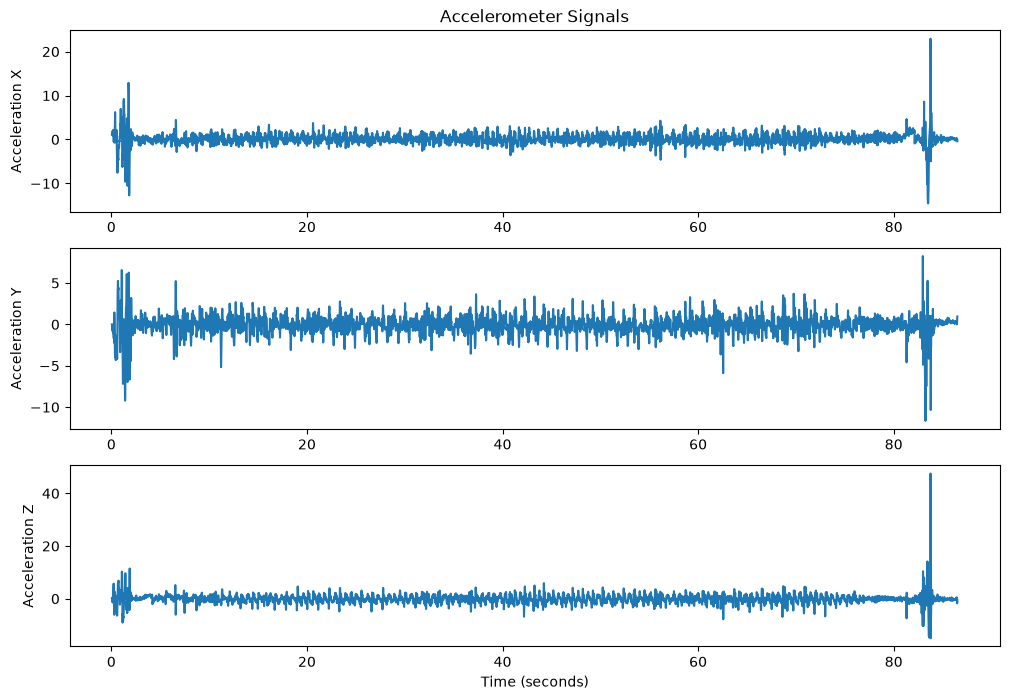

In [8]:
#Plot graph

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(df["seconds_elapsed"], df["x"])
plt.ylabel("Acceleration X")
plt.title("Accelerometer Signals")
plt.subplot(3, 1, 2)
plt.plot(df["seconds_elapsed"], df["y"])
plt.ylabel("Acceleration Y")
plt.subplot(3, 1, 3)
plt.plot(df["seconds_elapsed"], df["z"])
plt.ylabel("Acceleration Z")
plt.xlabel("Time (seconds)")


In [9]:
#Acceleration of a smooth road
df = pd.read_csv('DATA/P03_S01/Accelerometer.csv')

#Dataframe information

df.head()
df.shape
df.columns  #column names
df.info()   #type of each column, number of non-null values


<class 'pandas.DataFrame'>
RangeIndex: 8643 entries, 0 to 8642
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             8643 non-null   int64  
 1   seconds_elapsed  8643 non-null   float64
 2   z                8643 non-null   float64
 3   y                8643 non-null   float64
 4   x                8643 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 337.7 KB


Text(0.5, 0, 'Time (seconds)')

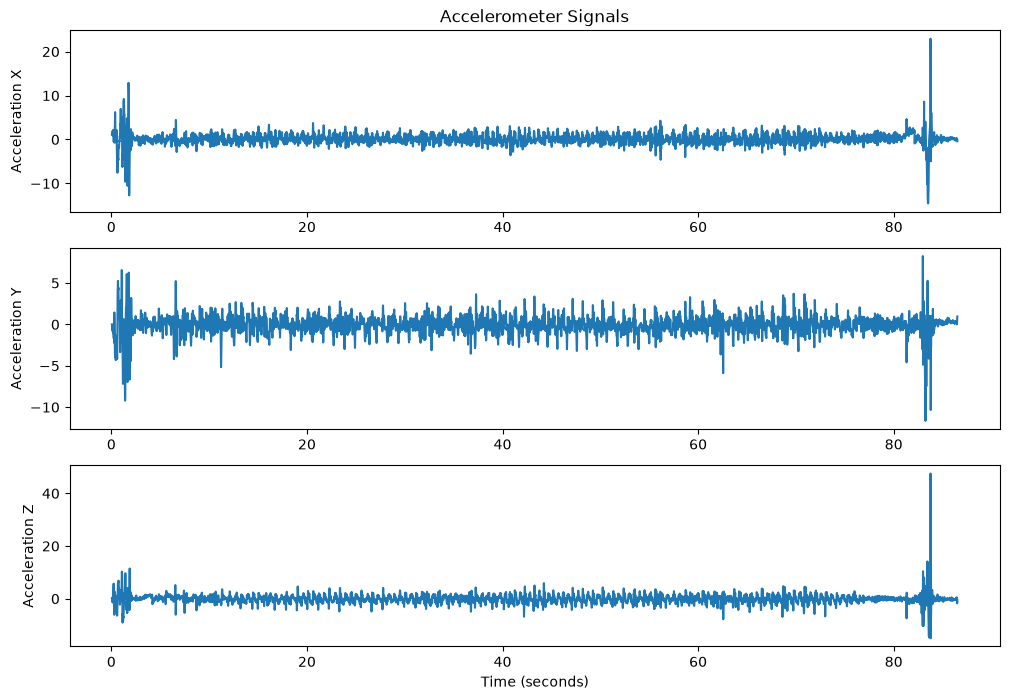

In [10]:
#Plot graph

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(df["seconds_elapsed"], df["x"])
plt.ylabel("Acceleration X")
plt.title("Accelerometer Signals")
plt.subplot(3, 1, 2)
plt.plot(df["seconds_elapsed"], df["y"])
plt.ylabel("Acceleration Y")
plt.subplot(3, 1, 3)
plt.plot(df["seconds_elapsed"], df["z"])
plt.ylabel("Acceleration Z")
plt.xlabel("Time (seconds)")

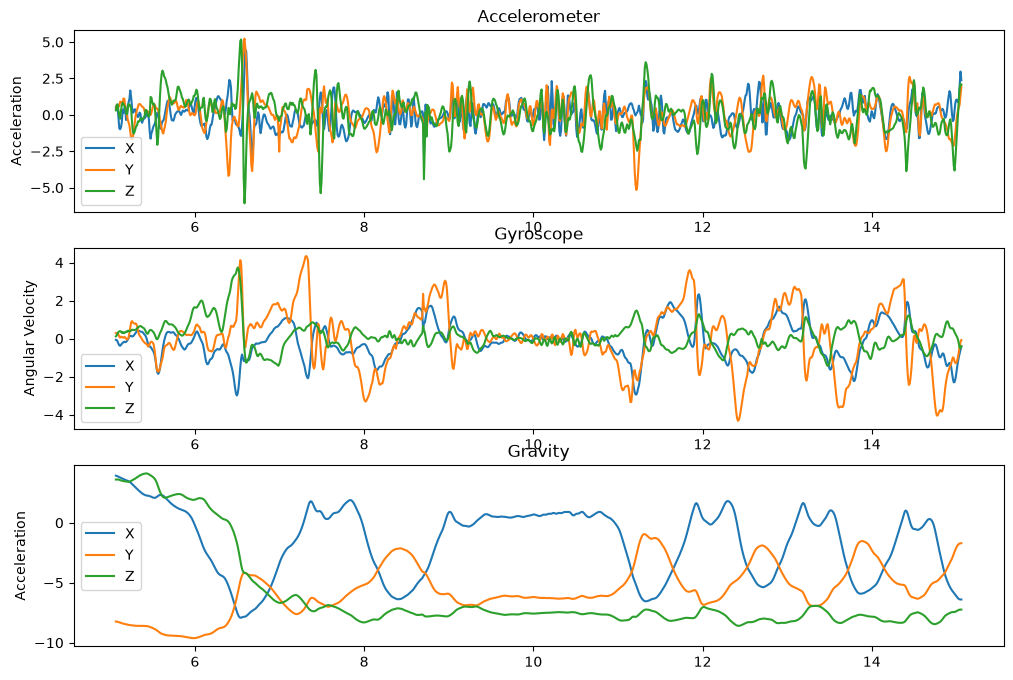

In [11]:
acc = pd.read_csv('DATA/P03_S01/Accelerometer.csv')
gyr = pd.read_csv('DATA/P03_S01/Gyroscope.csv')
grav = pd.read_csv('DATA/P03_S01/Gravity.csv')

sample_start = 500
sample_number = 1000
sample_end = sample_start + sample_number
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["x"][sample_start:sample_end], label="X")
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["y"][sample_start:sample_end], label="Y")
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["z"][sample_start:sample_end], label="Z")
plt.title("Accelerometer")
plt.ylabel("Acceleration")
plt.legend()
label="X"
label="Y"
label="Z"

plt.subplot(3, 1, 2)
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["x"][sample_start:sample_end], label="X")
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["y"][sample_start:sample_end], label="Y")
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["z"][sample_start:sample_end], label="Z")
plt.title("Gyroscope")
plt.ylabel("Angular Velocity")
plt.legend()
label="X"
label="Y"
label="Z"

plt.subplot(3, 1, 3)
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["x"][sample_start:sample_end], label="X")
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["y"][sample_start:sample_end], label="Y")
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["z"][sample_start:sample_end], label="Z")
plt.title("Gravity")
plt.ylabel("Acceleration")
plt.legend()
label="X"
label="Y"

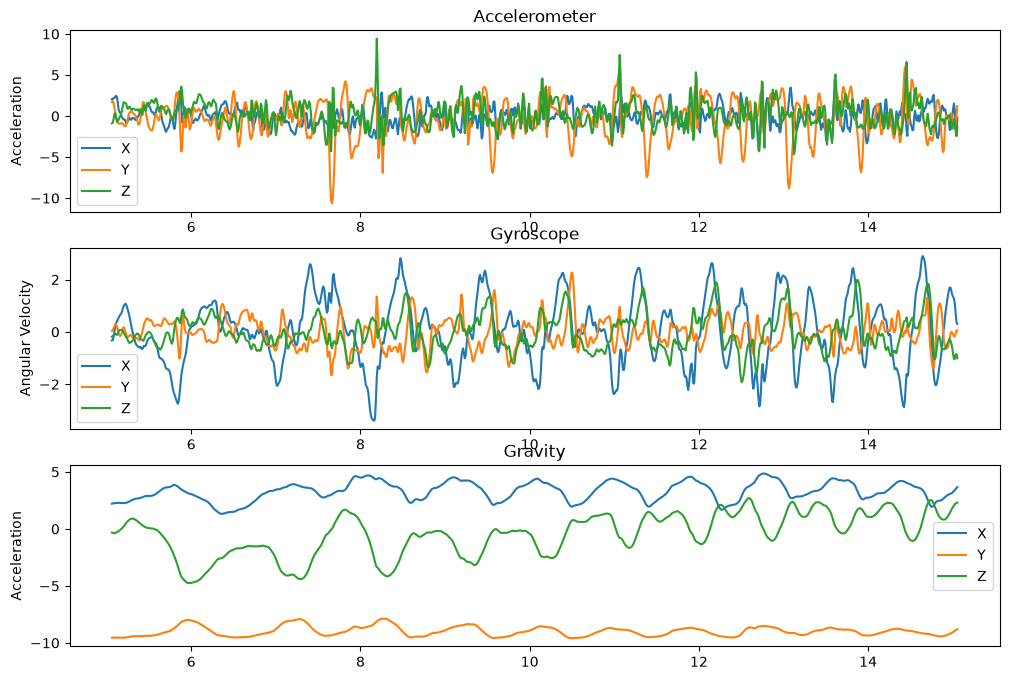

In [12]:
acc = pd.read_csv('DATA/P03_B01/Accelerometer.csv')
gyr = pd.read_csv('DATA/P03_B01/Gyroscope.csv')
grav = pd.read_csv('DATA/P03_B01/Gravity.csv')

sample_start = 500
sample_number = 1000
sample_end = sample_start + sample_number
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["x"][sample_start:sample_end], label="X")
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["y"][sample_start:sample_end], label="Y")
plt.plot(acc["seconds_elapsed"][sample_start:sample_end], acc["z"][sample_start:sample_end], label="Z")
plt.title("Accelerometer")
plt.ylabel("Acceleration")
plt.legend()
label="X"
label="Y"
label="Z"

plt.subplot(3, 1, 2)
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["x"][sample_start:sample_end], label="X")
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["y"][sample_start:sample_end], label="Y")
plt.plot(gyr["seconds_elapsed"][sample_start:sample_end], gyr["z"][sample_start:sample_end], label="Z")
plt.title("Gyroscope")
plt.ylabel("Angular Velocity")
plt.legend()
label="X"
label="Y"
label="Z"

plt.subplot(3, 1, 3)
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["x"][sample_start:sample_end], label="X")
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["y"][sample_start:sample_end], label="Y")
plt.plot(grav["seconds_elapsed"][sample_start:sample_end], grav["z"][sample_start:sample_end], label="Z")
plt.title("Gravity")
plt.ylabel("Acceleration")
plt.legend()
label="X"
label="Y"

In [13]:
acc.head

<bound method NDFrame.head of                       time  seconds_elapsed         z         y         x
0      1789021725168081200         0.061081  0.365173  0.062416 -0.046858
1      1789021725178082800         0.071083  0.530279  0.035254  0.085074
2      1789021725188085000         0.081085  0.599253  0.100425  0.282690
3      1789021725198087000         0.091087  0.577153  0.158273  0.387016
4      1789021725208088800         0.101089  0.497761  0.152390  0.408698
...                    ...              ...       ...       ...       ...
12444  1789021849631636700       124.524637 -0.416970  0.124601 -0.095672
12445  1789021849641638100       124.534638 -1.359728  0.131461  0.028284
12446  1789021849651640000       124.544640 -1.852286  0.202509  0.262770
12447  1789021849661642000       124.554642 -1.766840  0.327133  0.356570
12448  1789021849671644000       124.564644 -1.337017  0.254464  0.268311

[12449 rows x 5 columns]>

In [14]:
import pandas as pd
from pathlib import Path


def load_recording(folder_path, tolerance=0.006):

    folder_path = Path(folder_path)

    # Load the three sensors
    acc = pd.read_csv(folder_path / "Accelerometer.csv")
    gyro = pd.read_csv(folder_path / "Gyroscope.csv")
    gravity = pd.read_csv(folder_path / "Gravity.csv")

    # Rename sensor columns
    acc = acc.rename(columns={
        "x": "acc_x",
        "y": "acc_y",
        "z": "acc_z"
    })

    gyro = gyro.rename(columns={
        "seconds_elapsed": "gyro_time",
        "x": "gyro_x",
        "y": "gyro_y",
        "z": "gyro_z"
    })

    gravity = gravity.rename(columns={
        "seconds_elapsed": "grav_time",
        "x": "grav_x",
        "y": "grav_y",
        "z": "grav_z"
    })

    # Keep only useful columns
    acc = acc[
        ["seconds_elapsed", "acc_x", "acc_y", "acc_z"]
    ]

    gyro = gyro[
        ["gyro_time", "gyro_x", "gyro_y", "gyro_z"]
    ]

    gravity = gravity[
        ["grav_time", "grav_x", "grav_y", "grav_z"]
    ]

    # Sort by time
    acc = acc.sort_values("seconds_elapsed")
    gyro = gyro.sort_values("gyro_time")
    gravity = gravity.sort_values("grav_time")


    # Merge accelerometer + gyroscope
    merged = pd.merge_asof(
        acc,
        gyro,
        left_on="seconds_elapsed",
        right_on="gyro_time",
        direction="nearest",
        tolerance=tolerance
    )

    # Add gravity
    merged = pd.merge_asof(
        merged,
        gravity,
        left_on="seconds_elapsed",
        right_on="grav_time",
        direction="nearest",
        tolerance=tolerance
    )

    # Add information about recording
    recording_id = folder_path.name

    participant = recording_id.split("_")[0]
    condition = recording_id.split("_")[1]

    if condition.startswith("S"):
        surface = "smooth"
    elif condition.startswith("B"):
        surface = "bumpy"
    else:
        surface = "unknown"

    merged["participant"] = participant
    merged["surface"] = surface
    merged["recording_id"] = recording_id


    return merged

In [15]:
data_folder = Path("DATA")
recording_folders = [folder for folder in data_folder.iterdir()
                     if folder.is_dir()]
all_recordings = []

for folder in recording_folders:

    df_recording = load_recording(folder)

    all_recordings.append(df_recording)

In [16]:
recording_folders

[WindowsPath('DATA/P03_B01'),
 WindowsPath('DATA/P03_B02'),
 WindowsPath('DATA/P03_B03'),
 WindowsPath('DATA/P03_B04'),
 WindowsPath('DATA/P03_S01'),
 WindowsPath('DATA/P03_S02'),
 WindowsPath('DATA/P03_S03'),
 WindowsPath('DATA/P03_S04')]

In [17]:
all_recordings[1]

,seconds_elapsed,acc_x,acc_y,acc_z,gyro_time,gyro_x,gyro_y,gyro_z,grav_time,grav_x,grav_y,grav_z,participant,surface,recording_id
0,0.064427,-0.408473,-0.066374,0.459749,0.064427,-0.090487,0.496795,0.477278,0.064427,1.007621,5.181885,8.264572,P03,bumpy,P03_B02
1,0.074431,-0.247790,-0.072417,0.404320,0.074431,-0.011097,0.559101,0.499700,0.074431,0.989693,5.172815,8.272417,P03,bumpy,P03_B02
2,0.084434,-0.027076,-0.051565,0.311379,0.084434,0.043900,0.649402,0.493122,0.084434,0.965453,5.169470,8.277371,P03,bumpy,P03_B02
3,0.094438,0.192967,-0.030090,0.187568,0.094438,0.066159,0.736217,0.475980,0.094438,0.933206,5.169543,8.281023,P03,bumpy,P03_B02
4,0.104441,0.323444,-0.009673,0.000461,0.104441,0.050040,0.809735,0.439602,0.104441,0.892660,5.170374,8.284973,P03,bumpy,P03_B02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11201,112.108488,-0.095560,0.133651,0.000714,112.108488,0.340523,0.250432,0.071144,112.108488,0.289490,5.823871,7.884739,P03,bumpy,P03_B02
11202,112.118490,-0.243426,0.125321,-0.569016,112.118490,0.176661,0.185783,0.118092,112.118490,0.277544,5.844171,7.870134,P03,bumpy,P03_B02
11203,112.128491,-0.282458,0.275248,-1.085304,112.128491,-0.015811,0.028102,0.060795,112.128491,0.274228,5.850317,7.865683,P03,bumpy,P03_B02
11204,112.138493,-0.128722,0.489721,-1.237155,112.138493,-0.187907,-0.120933,-0.007944,112.138493,0.279706,5.842044,7.871637,P03,bumpy,P03_B02


In [18]:
type(all_recordings)

list

### Trimming

In [19]:
def trim_recordings(recordings, trim_seconds):
    
    trimmed_recordings = []

    for df in recordings:
        
        start_time = df["seconds_elapsed"].min() + trim_seconds
        end_time = df["seconds_elapsed"].max() - trim_seconds

        trimmed_df = df[
            (df["seconds_elapsed"] >= start_time) &
            (df["seconds_elapsed"] <= end_time)
        ].copy()

        trimmed_df = trimmed_df.reset_index(drop=True)

        trimmed_recordings.append(trimmed_df)

    return trimmed_recordings

In [20]:
trimmed_recordings = trim_recordings(
    all_recordings,
    trim_seconds=5
)

### Sanity Checks

In [21]:
summary = []

for df in trimmed_recordings:

    recording_id = df["recording_id"].iloc[0]

    duration = (
        df["seconds_elapsed"].max()
        - df["seconds_elapsed"].min()
    )

    missing_values = df.isnull().sum().sum()

    duplicated_times = (
        df["seconds_elapsed"]
        .duplicated()
        .sum()
    )

    samples = len(df)

    sampling_rate = samples / duration

    summary.append({
        "recording_id": recording_id,
        "samples": samples,
        "duration_seconds": duration,
        "missing_values": missing_values,
        "duplicated_times": duplicated_times,
        "sampling_rate_hz": sampling_rate
    })

In [22]:
summary_df = pd.DataFrame(summary)
summary_df 


,recording_id,samples,duration_seconds,missing_values,duplicated_times,sampling_rate_hz
0,P03_B01,11449,114.501104,0,0,99.990302
1,P03_B02,10207,102.081623,0,0,99.988614
2,P03_B03,5370,53.709350,0,0,99.982592
3,P03_B04,5300,53.009007,0,0,99.983008
4,P03_S01,7644,76.447614,0,0,99.990041
5,P03_S02,6911,69.127485,0,0,99.974706
6,P03_S03,5205,52.056451,0,0,99.987607
7,P03_S04,5634,56.347367,0,0,99.986926


In [23]:
print(
    "Minimum duration:",
    summary_df["duration_seconds"].min(),
    "seconds"
)

print(
    "Maximum duration:",
    summary_df["duration_seconds"].max(),
    "seconds"
)

print(
    "Mean duration:",
    summary_df["duration_seconds"].mean(),
    "seconds"
)

Minimum duration: 52.056451171875004 seconds
Maximum duration: 114.50110424804687 seconds
Mean duration: 72.16000012207031 seconds


## Windowing

In [24]:
def create_windows(df, sampling_rate=100, window_seconds=20, overlap_seconds=5):

    windows = []

    # Convert seconds to samples
    window_size = int(window_seconds * sampling_rate)
    overlap_size = int(overlap_seconds * sampling_rate)

    # How far we move forward each time
    step_size = window_size - overlap_size

    # Recording name, useful for keeping track of origin
    recording_id = df["recording_id"].iloc[0]

    window_number = 0

    for start in range(0, len(df) - window_size + 1, step_size):

        end = start + window_size

        window = df.iloc[start:end].copy()

        # Add useful identification
        window["window_id"] = f"{recording_id}_W{window_number}"

        windows.append(window)

        window_number += 1

    return windows

In [25]:
all_windows = []

for df in trimmed_recordings:

    recording_windows = create_windows(
        df,
        sampling_rate=100,
        window_seconds=20,
        overlap_seconds=5
    )

    all_windows.extend(recording_windows)

In [26]:
all_windows[0].shape

(2000, 16)

In [27]:
len(all_windows)

33

In [28]:
for df in trimmed_recordings:

    windows = create_windows(
        df,
        sampling_rate=100,
        window_seconds=20,
        overlap_seconds=5
    )

    print(
        df["recording_id"].iloc[0],
        len(windows)
    )

P03_B01 7
P03_B02 6
P03_B03 3
P03_B04 3
P03_S01 4
P03_S02 4
P03_S03 3
P03_S04 3


In [29]:
all_windows[0].head()

,seconds_elapsed,acc_x,acc_y,acc_z,gyro_time,gyro_x,gyro_y,gyro_z,grav_time,grav_x,grav_y,grav_z,participant,surface,recording_id,window_id
0,5.062099,2.062881,1.693573,-0.881930,5.062099,-0.328537,0.035927,-0.185941,5.062099,2.210619,-9.548948,-0.318014,P03,bumpy,P03_B01,P03_B01_W0
1,5.072101,2.130914,1.830666,-0.806646,5.072101,-0.315711,0.072252,-0.167311,5.072101,2.227880,-9.543886,-0.348108,P03,bumpy,P03_B01,P03_B01_W0
2,5.082103,2.111698,1.542025,-0.392855,5.082103,-0.184462,0.132252,-0.120976,5.082103,2.242158,-9.539708,-0.370296,P03,bumpy,P03_B01,P03_B01_W0
3,5.092106,2.214304,1.027301,0.235518,5.092106,0.026836,0.215038,-0.078345,5.092106,2.252229,-9.537192,-0.373933,P03,bumpy,P03_B01,P03_B01_W0
4,5.102108,2.332259,0.382559,0.360566,5.102108,0.213055,0.284125,-0.079786,5.102108,2.260568,-9.535890,-0.356376,P03,bumpy,P03_B01,P03_B01_W0


In [30]:
window = all_windows[0]
acc = window["acc_x"]
acc.shape



(2000,)

## Feature Extraction

In [31]:
def extract_features(window):

    window = window.copy()

    # Magnitudes
    window["acc_magnitude"] = np.sqrt(
        window["acc_x"]**2 +
        window["acc_y"]**2 +
        window["acc_z"]**2
    )

    window["gyro_magnitude"] = np.sqrt(
        window["gyro_x"]**2 +
        window["gyro_y"]**2 +
        window["gyro_z"]**2
    )

    sensor_columns = [
        "acc_x", "acc_y", "acc_z",
        "gyro_x", "gyro_y", "gyro_z",
        "grav_x", "grav_y", "grav_z",
        "acc_magnitude",
        "gyro_magnitude"
    ]

    features = {}

    for column in sensor_columns:

        signal = window[column]

        features[f"{column}_mean"] = signal.mean()
        features[f"{column}_std"] = signal.std()
        features[f"{column}_min"] = signal.min()
        features[f"{column}_max"] = signal.max()
        features[f"{column}_range"] = signal.max() - signal.min()
        features[f"{column}_median"] = signal.median()
        features[f"{column}_rms"] = np.sqrt(np.mean(signal ** 2))

    features["recording_id"] = window["recording_id"].iloc[0]
    features["window_id"] = window["window_id"].iloc[0]
    features["surface"] = window["surface"].iloc[0]

    return features


In [32]:
feature_list = []

for window in all_windows:
    feature_list.append(extract_features(window))

features_df = pd.DataFrame(feature_list)

In [33]:
features_df.head()


,acc_x_mean,acc_x_std,acc_x_min,acc_x_max,acc_x_range,acc_x_median,acc_x_rms,acc_y_mean,acc_y_std,acc_y_min,...,gyro_magnitude_mean,gyro_magnitude_std,gyro_magnitude_min,gyro_magnitude_max,gyro_magnitude_range,gyro_magnitude_median,gyro_magnitude_rms,recording_id,window_id,surface
0,-0.006626,1.339255,-4.777415,7.695404,12.472819,0.001314,1.338937,-0.146142,2.770218,-19.277253,...,1.270740,0.719350,0.099544,4.599198,4.499654,1.105711,1.460132,P03_B01,P03_B01_W0,bumpy
1,0.118104,1.479844,-5.714433,5.618283,11.332716,0.075969,1.484180,-0.069858,2.732351,-17.279510,...,1.237602,0.669692,0.086445,4.599198,4.512752,1.108236,1.407097,P03_B01,P03_B01_W1,bumpy
2,0.059072,1.663293,-6.164707,6.668047,12.832754,0.038789,1.663926,-0.084452,3.234809,-19.214151,...,1.178442,0.593337,0.068823,4.531969,4.463147,1.074944,1.319317,P03_B01,P03_B01_W2,bumpy
3,0.095303,1.592649,-6.755304,7.334781,14.090085,0.093698,1.595101,-0.046725,2.906060,-14.857974,...,1.124138,0.563384,0.042518,3.072942,3.030424,1.038588,1.257351,P03_B01,P03_B01_W3,bumpy
4,0.061348,1.557009,-5.280067,6.614167,11.894234,-0.000142,1.557828,-0.082041,2.909151,-19.433005,...,1.037563,0.525400,0.042518,3.941740,3.899221,0.959635,1.162946,P03_B01,P03_B01_W4,bumpy


In [34]:
features_df.shape


(33, 80)

In [35]:
features_df["surface"].value_counts()

surface
bumpy     19
smooth    14
Name: count, dtype: int64

### Select Train & Test Data

Make a group aware split separate complete recordings between training and testing.


In [36]:
# ============================================================
# STEP 0: PREPARE TRAIN / TEST DATA
# ============================================================

# We keep complete recordings together.
# These recordings will be used ONLY for the final test.
test_recordings = [
    "P03_B04",
    "P03_S04"
]

# True for windows belonging to test recordings
test_mask = features_df["recording_id"].isin(test_recordings)

# X = numerical features
# Remove identifiers and target label

X = features_df.drop(
    columns=["surface", "recording_id", "window_id"]
)

# y = target
# smooth or bumpy

y = features_df["surface"]

# Groups tell us which original recording each window came from

groups = features_df["recording_id"]

# ------------------------------------------------------------
# Split train and final test
# ------------------------------------------------------------

X_train = X[~test_mask] #except from the test set
X_test = X[test_mask]

y_train = y[~test_mask] #except from the test set
y_test = y[test_mask]

groups_train = groups[~test_mask]

# ------------------------------------------------------------
# Check split
# ------------------------------------------------------------

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("Training labels:")
print(y_train.value_counts())

print("\nTesting labels:") #\n means leave a line before print
print(y_test.value_counts())

print("Training recordings:")
print(
    features_df.loc[~test_mask, "recording_id"].unique() #Show me the unique recording IDs that belong to the training set
)

print("\nTesting recordings:")
print(
    features_df.loc[test_mask, "recording_id"].unique() #Show me the unique recording IDs that belong to the test set
)


Training shape: (27, 77)
Testing shape: (6, 77)
Training labels:
surface
bumpy     16
smooth    11
Name: count, dtype: int64

Testing labels:
surface
bumpy     3
smooth    3
Name: count, dtype: int64
Training recordings:
<StringArray>
['P03_B01', 'P03_B02', 'P03_B03', 'P03_S01', 'P03_S02', 'P03_S03']
Length: 6, dtype: str

Testing recordings:
<StringArray>
['P03_B04', 'P03_S04']
Length: 2, dtype: str


# Feature selection

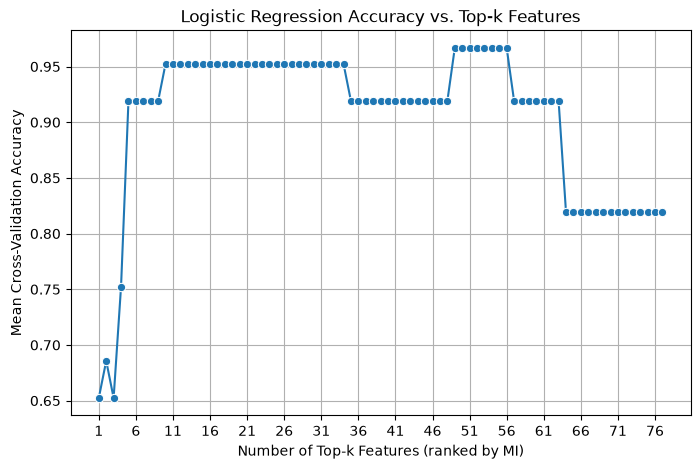


Best number of features: 49
Best cross-validation accuracy: 0.967

Selected features:
acc_y_min
acc_y_std
acc_y_rms
acc_x_rms
acc_magnitude_std
acc_x_std
acc_magnitude_rms
acc_y_range
acc_x_min
acc_x_range
acc_y_max
acc_magnitude_mean
acc_magnitude_max
acc_magnitude_median
acc_magnitude_range
acc_x_max
grav_x_mean
grav_x_median
acc_z_max
grav_z_max
grav_y_range
grav_z_mean
gyro_magnitude_mean
grav_z_min
grav_y_std
gyro_y_max
gyro_magnitude_rms
gyro_magnitude_median
grav_z_median
gyro_magnitude_std
gyro_x_max
acc_z_std
acc_z_rms
acc_z_range
acc_magnitude_min
gyro_x_range
gyro_z_min
grav_z_rms
gyro_y_median
grav_x_rms
acc_y_median
grav_y_min
grav_x_max
gyro_z_range
gyro_y_range
gyro_y_rms
gyro_z_max
gyro_x_median
gyro_y_std

Mutual Information ranking:


,feature,MI_score
9,acc_y_min,0.637327
8,acc_y_std,0.620206
6,acc_x_rms,0.607860
1,acc_x_std,0.607860
13,acc_y_rms,0.607860
...,...,...
21,gyro_x_mean,0.026009
5,acc_x_median,0.020381
35,gyro_z_mean,0.007227
0,acc_x_mean,0.000000



Final test accuracy: 1.0

Confusion Matrix:
[[3 0]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

       bumpy       1.00      1.00      1.00         3
      smooth       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



In [37]:
# ============================================================
# FEATURE SELECTION WITH MUTUAL INFORMATION
# Adapted from the lab-session code
# ============================================================


# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import StratifiedGroupKFold

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# STEP 1: GROUP-AWARE CROSS-VALIDATION
# ============================================================

# We use the training recordings to choose the best
# number of features.
#
# Complete recordings stay together during validation.

cv = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Number of extracted features

total_features = X_train.shape[1]


# Store the mean validation accuracy for each value of k

accuracy_list = []


# ============================================================
# STEP 2: TRY DIFFERENT NUMBERS OF FEATURES
# ============================================================

for k in range(1, total_features + 1):

    fold_accuracies = []


    # --------------------------------------------------------
    # Cross-validation loop
    # --------------------------------------------------------

    for train_index, val_index in cv.split(
        X_train,
        y_train,
        groups=groups_train
    ):

        # Training part of this fold

        X_fold_train = X_train.iloc[train_index]
        y_fold_train = y_train.iloc[train_index]


        # Validation part of this fold

        X_fold_val = X_train.iloc[val_index]
        y_fold_val = y_train.iloc[val_index]


        # ----------------------------------------------------
        # Scale features
        # ----------------------------------------------------

        # Fit scaler ONLY on training fold

        scaler = StandardScaler()


        X_fold_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_fold_train),
            columns=X_fold_train.columns
        )


        # Use same scaler for validation fold

        X_fold_val_scaled = pd.DataFrame(
            scaler.transform(X_fold_val),
            columns=X_fold_val.columns
        )


        # ----------------------------------------------------
        # Compute Mutual Information scores
        # ----------------------------------------------------

        # MI uses ONLY the training fold

        mi_scores = mutual_info_classif(
            X_fold_train_scaled,
            y_fold_train,
            random_state=42
        )


        # Sort feature indices from highest MI to lowest

        feature_ranking = np.argsort(mi_scores)[::-1]


        # Select the best k features

        top_k_features = X_fold_train_scaled.columns[
            feature_ranking[:k]
        ]


        # ----------------------------------------------------
        # Train Logistic Regression
        # ----------------------------------------------------

        model = LogisticRegression(
            max_iter=5000,
            random_state=42
        )


        model.fit(
            X_fold_train_scaled[top_k_features],
            y_fold_train
        )


        # ----------------------------------------------------
        # Predict validation data
        # ----------------------------------------------------

        y_pred = model.predict(
            X_fold_val_scaled[top_k_features]
        )


        # Calculate validation accuracy

        fold_accuracy = accuracy_score(
            y_fold_val,
            y_pred
        )


        fold_accuracies.append(
            fold_accuracy
        )


    # --------------------------------------------------------
    # Mean accuracy across validation folds
    # --------------------------------------------------------

    mean_accuracy = np.mean(
        fold_accuracies
    )


    accuracy_list.append(
        mean_accuracy
    )



# ============================================================
# STEP 3: PLOT ACCURACY VS NUMBER OF FEATURES
# ============================================================

plt.figure(figsize=(8, 5))

sns.lineplot(
    x=range(1, total_features + 1),
    y=accuracy_list,
    marker="o"
)

plt.xlabel(
    "Number of Top-k Features (ranked by MI)"
)

plt.ylabel(
    "Mean Cross-Validation Accuracy"
)

plt.title(
    "Logistic Regression Accuracy vs. Top-k Features"
)

plt.xticks(
    range(
        1,
        total_features + 1,
        5
    )
)

plt.grid(True)

plt.show()



# ============================================================
# STEP 4: FIND THE BEST NUMBER OF FEATURES
# ============================================================

best_k = np.argmax(
    accuracy_list
) + 1


print(
    "\nBest number of features:",
    best_k
)

print(
    "Best cross-validation accuracy:",
    round(
        max(accuracy_list),
        3
    )
)



# ============================================================
# STEP 5: SCALE THE COMPLETE TRAINING DATA
# ============================================================

# Now that k has been selected,
# fit scaler on ALL training data.

scaler = StandardScaler()


X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)


# Transform final test data using the SAME scaler

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)



# ============================================================
# STEP 6: COMPUTE FINAL MUTUAL INFORMATION RANKING
# ============================================================

# Calculate MI scores using ALL training data

mi_scores = mutual_info_classif(
    X_train_scaled,
    y_train,
    random_state=42
)


# Rank features

feature_ranking = np.argsort(
    mi_scores
)[::-1]


# Select the best k features

top_k_features = X_train_scaled.columns[
    feature_ranking[:best_k]
]



# ------------------------------------------------------------
# Show selected features
# ------------------------------------------------------------

print("\nSelected features:")

for feature in top_k_features:
    print(feature)



# ------------------------------------------------------------
# Create MI ranking table
# ------------------------------------------------------------

mi_table = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "MI_score": mi_scores
})


mi_table = mi_table.sort_values(
    "MI_score",
    ascending=False
)


print("\nMutual Information ranking:")

display(mi_table)



# ============================================================
# STEP 7: TRAIN FINAL LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(
    max_iter=5000,
    random_state=42
)


model.fit(
    X_train_scaled[top_k_features],
    y_train
)



# ============================================================
# STEP 8: FINAL TEST PREDICTION
# ============================================================

# The final test recordings are used for the first time here.

y_pred = model.predict(
    X_test_scaled[top_k_features]
)



# ============================================================
# STEP 9: FINAL TEST ACCURACY
# ============================================================

test_accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
    "\nFinal test accuracy:",
    round(
        test_accuracy,
        3
    )
)



# ============================================================
# STEP 10: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nConfusion Matrix:")

print(cm)



# ============================================================
# STEP 11: CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

In [38]:
selected_features = 10
top_selected_featues = top_k_features[:selected_features]
X_train_scaled[top_selected_featues]

,acc_y_min,acc_y_std,acc_y_rms,acc_x_rms,acc_magnitude_std,acc_x_std,acc_magnitude_rms,acc_y_range,acc_x_min,acc_x_range
0,-1.487058,1.243168,1.247398,0.376866,1.100557,0.390100,0.983870,1.391990,0.219725,0.362205
1,-1.170291,1.199560,1.200234,0.682789,0.904399,0.685282,1.065916,1.157533,-0.036062,0.161045
2,-1.477052,1.778190,1.780919,1.061384,1.444385,1.070456,1.619191,1.418560,-0.158978,0.425712
3,-0.786326,1.399603,1.400306,0.916418,1.133757,0.922130,1.308690,0.790820,-0.320200,0.647556
4,-1.511754,1.403162,1.404779,0.837911,1.300139,0.847299,1.274685,1.283242,0.082511,0.260119
5,-1.511754,1.034547,1.041635,0.536917,0.797461,0.487893,0.891187,1.439855,0.275953,0.070944
6,-0.050118,0.630626,0.628484,0.323633,0.432394,0.287789,0.586141,0.367394,0.100983,-0.147548
7,-1.122006,0.492116,0.489617,1.041543,0.920156,1.051127,0.665885,0.940983,-1.914783,1.638359
8,-1.122006,0.934088,0.933061,1.610675,1.121384,1.609334,1.155866,1.003176,-1.914783,1.662125
9,-0.106286,0.554037,0.551739,1.297992,0.722632,1.301590,0.745890,0.473266,-1.008718,1.197568


# Clustering

## Hierarchical clustering

##### Transfrom string to numerical values

In [39]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

In [40]:

# Plotting function
def plot_dendrogram(Z, window_labels, distance_threshold=0.0):
    # Create a figure with two subplots
    fig, axs = plt.subplots(1, 2, figsize=(20, 8))

    # Plot the truncated dendrogram (top 3 levels)
    dendrogram(Z, 
               truncate_mode='level',  
               p=3,                    
               labels=window_labels,        
               leaf_rotation=90,        
               leaf_font_size=8,      
               ax=axs[0])              
    axs[0].axhline(y=distance_threshold, color='r', linestyle='--')
    axs[0].set_title("Dendrogram (Top 3 Levels)")
    axs[0].set_xlabel("Window ID or grouped window count")
    axs[0].set_ylabel("Distance")

    # Plot the full dendrogram (all levels)
    dendrogram(Z, 
               truncate_mode=None,  
               labels=window_labels,     
               leaf_rotation=90,     
               leaf_font_size=8,   
               ax=axs[1],           
               show_leaf_counts=False)  
    axs[1].axhline(y=distance_threshold, color='r', linestyle='--')
    axs[1].set_title("Dendrogram (Full)")
    axs[1].set_xlabel("Window ID")  
    axs[1].set_ylabel("Distance")

    # Set the main title for the entire figure
    plt.suptitle(f"Single-linkage dendrograms - threshold = {distance_threshold:g}")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()



# Window IDs in the same row order used to compute Z.
window_labels = features_df.loc[X_train.index, "window_id"].tolist()

# Use the results for plotting
plot_dendrogram(Z, window_labels, distance_threshold)


NameError: name 'Z' is not defined

Number of clusters formed: 2


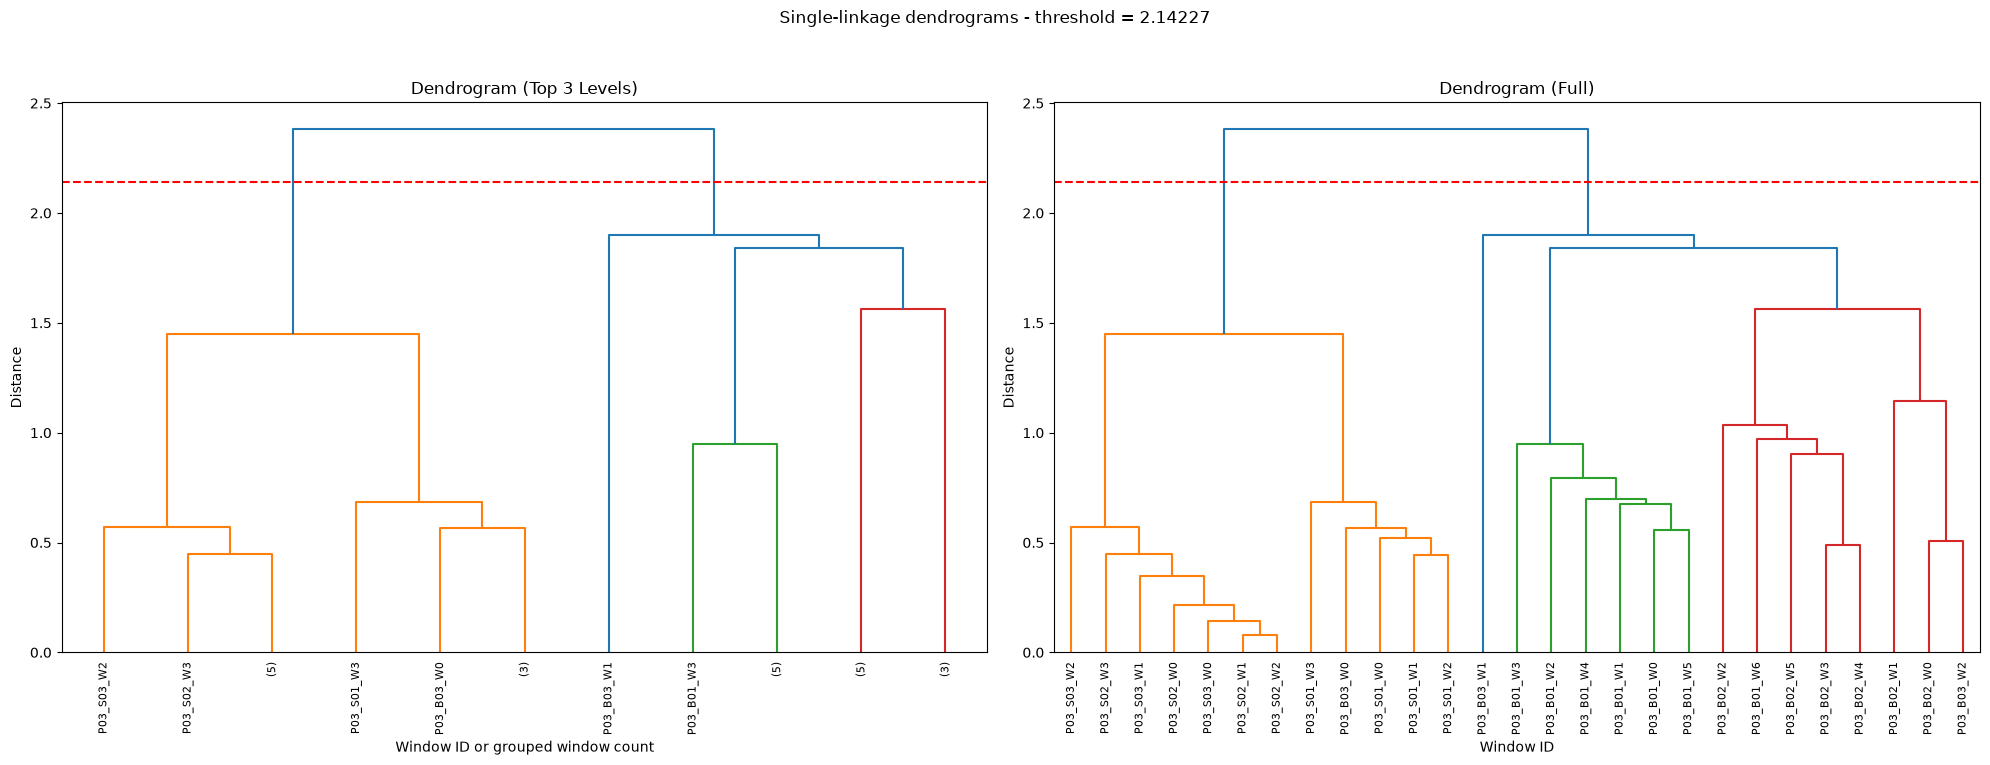

In [ ]:
# write your Clustering function here
def perform_clustering(data, method="single"):
    Z = linkage(data, method=method)

    # Explicitly create two clusters.
    clusters = cut_tree(Z, n_clusters=2).flatten()

    # Height used only to illustrate the split on the dendrogram.
    distance_threshold = (Z[-2, 2] + Z[-1, 2]) / 2

    if Z[-2, 2] == Z[-1, 2]:
        print("Tied merge heights: a horizontal line cannot show "
              "the exact two-cluster split.")

    print(f"Number of clusters formed: {len(np.unique(clusters))}")

    return Z, clusters, distance_threshold


Z, clusters, distance_threshold = perform_clustering(
    X_train_scaled[top_selected_featues],
    method="single"
)

window_labels = features_df.loc[
    X_train.index, "window_id"
].tolist()

plot_dendrogram(Z, window_labels, distance_threshold)




Training-window label-matched agreement: 96.3%


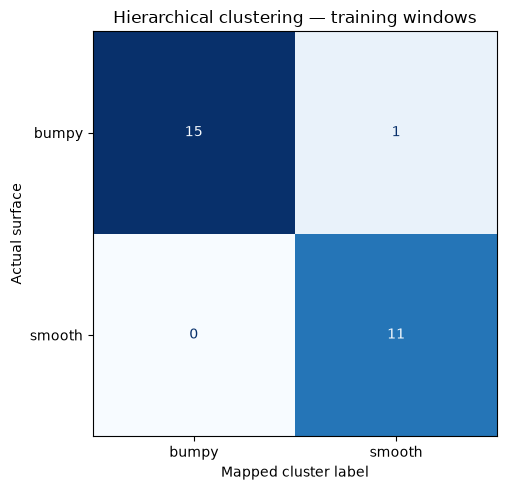

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

def evaluate_clustering(clusters, true_labels):
    true_labels = np.asarray(true_labels)

    # Check both possible cluster-to-class mappings.
    accuracy_original = np.mean(clusters == true_labels)
    accuracy_swapped = np.mean((1 - clusters) == true_labels)

    if accuracy_swapped > accuracy_original:
        predicted_labels = 1 - clusters
    else:
        predicted_labels = clusters.copy()

    accuracy = np.mean(predicted_labels == true_labels)

    print(f"Training-window label-matched agreement: {accuracy:.1%}")

    # Use the SAME mapping for accuracy and the confusion matrix.
    cm = confusion_matrix(
        true_labels,
        predicted_labels,
        labels=[0, 1]
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    ax.set_title("Hierarchical clustering — training windows")
    ax.set_xlabel("Mapped cluster label")
    ax.set_ylabel("Actual surface")
    plt.tight_layout()
    plt.show()

    return accuracy, predicted_labels


clustering_accuracy, mapped_labels = evaluate_clustering(
    clusters,
    y_train_encoded
)